# NCA vegetation FCM — coarse K=5, m=1.33 + species subcluster diagnostics

This is a focused refit of the vegetation parent space at **K = 5** and **m = 1.33**.

It intentionally preserves the final vegetation-clustering workflow:

- input: `C:\NCA_DATA\Vegetation Data\NCA_Master_Aligned_spp_fg_through2026.csv`
- 10 functional-group variables
- row closure to proportional composition
- Hellinger transformation
- fuzzy c-means
- 20 starts
- random seeds beginning at 42
- `max_iter = 300`
- `tol = 1e-5`
- membership/core threshold = 0.60

This notebook does **not** redo species-level subclustering. Its purpose is to produce the independently fit coarse K=5 vegetation labels and then compare them directly with the retained K=8 parent solution.

K=5 cluster numbers are local labels. They should not be interpreted as equivalent to the existing P1–P8 numbering until the K5↔K8 crosswalk is inspected.

This version adds the same species-level subcluster diagnostic sweep used in the earlier vegetation workflow. To protect the already-completed K=5 run, it writes to a new output root: `Clustering_Veg\K5_m1p33_Subclusters`.

In [13]:
# =============================================================================
# 0. IMPORTS / PATHS / FIXED SETTINGS
# =============================================================================

from __future__ import annotations

import os
os.environ.setdefault("OMP_NUM_THREADS", "1")

from pathlib import Path
from itertools import combinations
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.spatial.distance import cdist, pdist

from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,
)

pd.set_option("display.max_columns", 150)
pd.set_option("display.width", 240)

COMBINED_PATH = Path(
    r"C:\NCA_DATA\Vegetation Data\NCA_Master_Aligned_spp_fg_through2026.csv"
)

K8_ASSIGNMENTS_PATH = Path(
    r"C:\NCA_DATA\Vegetation Data\Clustering_Veg\Derived"
    r"\NCA_FCM_K8_m1p33_parent_assignments.csv"
)

OUTPUT_DIR = (
    COMBINED_PATH.parent
    / "Clustering_Veg"
    / "K5_m1p33_Subclusters"
)

DERIVED_DIR = OUTPUT_DIR / "Derived"
TABLE_DIR = OUTPUT_DIR / "Tables"
FIG_DIR = OUTPUT_DIR / "Figures"

for d in [OUTPUT_DIR, DERIVED_DIR, TABLE_DIR, FIG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

K = 5
M = 1.33
N_STARTS = 20
RANDOM_STATE = 42
MAX_ITER = 300
TOL = 1e-5
CORE_MEMBERSHIP = 0.60

K5_LABELS = {
    1: "PBG",
    2: "ARTR",
    3: "Non-ARTR shrub",
    4: "Exotic forb",
    5: "EAG",
}

FG_ALL = [
    "ARTR_FG",
    "SHRUB_FG",
    "PBG_FG",
    "EAG_FG",
    "EF_FG",
    "BAREGROUND_FG",
    "BIOCRUST_FG",
    "LITTER_FG",
    "OTHER_FG",
    "NPF_FG",
]

FG_LABELS = {
    "ARTR_FG": "ARTR",
    "SHRUB_FG": "Shrub",
    "PBG_FG": "PBG",
    "EAG_FG": "EAG",
    "EF_FG": "EF",
    "BAREGROUND_FG": "Bare",
    "BIOCRUST_FG": "Biocrust",
    "LITTER_FG": "Litter",
    "OTHER_FG": "Other",
    "NPF_FG": "NPF",
}

print("Input:", COMBINED_PATH)
print("Existing K=8:", K8_ASSIGNMENTS_PATH)
print("Output:", OUTPUT_DIR)
print(f"K={K}, m={M:.2f}, starts={N_STARTS}")

Input: C:\NCA_DATA\Vegetation Data\NCA_Master_Aligned_spp_fg_through2026.csv
Existing K=8: C:\NCA_DATA\Vegetation Data\Clustering_Veg\Derived\NCA_FCM_K8_m1p33_parent_assignments.csv
Output: C:\NCA_DATA\Vegetation Data\Clustering_Veg\K5_m1p33_Subclusters
K=5, m=1.33, starts=20


## 1. Load the finalized vegetation master and reproduce the parent feature space

As before, parent clustering uses the ten functional-group columns only. Raw cover is row-closed and then Hellinger transformed:

\[
p_{ij}=\frac{x_{ij}}{\sum_j x_{ij}},
\qquad
h_{ij}=\sqrt{p_{ij}}.
\]

In [14]:
# =============================================================================
# 1. LOAD / VALIDATE / HELLINGER
# =============================================================================

if not COMBINED_PATH.exists():
    raise FileNotFoundError(COMBINED_PATH)

master = pd.read_csv(COMBINED_PATH, low_memory=False)
master = master.drop(
    columns=[c for c in master.columns if c.startswith("Unnamed:")],
    errors="ignore",
)

missing_fg = [c for c in FG_ALL if c not in master.columns]
if missing_fg:
    raise ValueError(
        f"Combined master is missing parent FG columns: {missing_fg}"
    )

fg_raw = (
    master[FG_ALL]
    .apply(pd.to_numeric, errors="coerce")
    .fillna(0.0)
)

row_sum = fg_raw.sum(axis=1).to_numpy()
keep_parent = row_sum > 0

if not np.all(keep_parent):
    warnings.warn(
        f"{np.sum(~keep_parent)} rows have zero total FG cover and cannot enter parent FCM."
    )

master_parent = master.loc[keep_parent].copy().reset_index(drop=True)
fg_raw = fg_raw.loc[keep_parent].reset_index(drop=True)

X_prop = (
    fg_raw.to_numpy(dtype=np.float64)
    / fg_raw.sum(axis=1).to_numpy()[:, None]
)
X = np.sqrt(X_prop)

print(f"Rows in combined master: {len(master):,}")
print(f"Rows entering FCM:       {len(master_parent):,}")
print(f"FG dimensions:           {X.shape[1]}")
print(f"Hellinger matrix:         {X.shape}")

print("\nRaw FG row-sum summary:")
display(
    fg_raw.sum(axis=1)
    .describe()
    .to_frame("FG row sum")
    .T
)

if len(master) != 1171:
    warnings.warn(
        "The retained final workflow had 1,171 rows. "
        f"Current file contains {len(master):,}."
    )

Rows in combined master: 1,171
Rows entering FCM:       1,171
FG dimensions:           10
Hellinger matrix:         (1171, 10)

Raw FG row-sum summary:


,count,mean,std,min,25%,50%,75%,max
FG row sum,1171.0,99.98883,0.110597,97.95,100.0,100.0,100.0,102.483333


## 2. Fuzzy c-means helpers

This is the same FCM formulation used in the retained vegetation workflow. The best of 20 starts is selected by minimum FCM objective.

Restart ARI is added here only as a reproducibility diagnostic; it does not participate in model selection.

In [15]:
# =============================================================================
# 2. FCM HELPERS
# =============================================================================

def init_membership(n: int, k: int, seed: int) -> np.ndarray:
    rng = np.random.default_rng(seed)
    U = rng.random((n, k))
    return U / U.sum(axis=1, keepdims=True)


def fuzzy_cmeans(
    X: np.ndarray,
    k: int,
    m: float,
    *,
    max_iter: int = 300,
    tol: float = 1e-5,
    seed: int = 42,
):
    if m <= 1:
        raise ValueError("FCM requires m > 1.")

    n = X.shape[0]
    eps = 1e-12
    U = init_membership(n, k, seed)
    converged = False

    for iteration in range(1, max_iter + 1):
        U_old = U.copy()

        Um = U ** m
        centers = (Um.T @ X) / (Um.sum(axis=0)[:, None] + eps)

        D = np.maximum(
            cdist(X, centers, metric="euclidean"),
            eps,
        )

        power = -2.0 / (m - 1.0)
        W = D ** power
        U = W / W.sum(axis=1, keepdims=True)

        if np.max(np.abs(U - U_old)) < tol:
            converged = True
            break

    Um = U ** m
    centers = (Um.T @ X) / (Um.sum(axis=0)[:, None] + eps)
    D = np.maximum(cdist(X, centers, metric="euclidean"), eps)
    objective = float(np.sum((U ** m) * (D ** 2)))

    return {
        "centers": centers,
        "U": U,
        "objective": objective,
        "iterations": iteration,
        "converged": converged,
        "seed": seed,
    }


def fit_fcm_all_starts(
    X: np.ndarray,
    k: int,
    m: float,
    *,
    n_starts: int = 20,
    random_state: int = 42,
    max_iter: int = 300,
    tol: float = 1e-5,
):
    fits = []

    for seed in range(random_state, random_state + n_starts):
        fit = fuzzy_cmeans(
            X,
            k,
            m,
            max_iter=max_iter,
            tol=tol,
            seed=seed,
        )
        fits.append(fit)

    return fits


def fcm_metrics(fit: dict) -> dict:
    U = fit["U"]
    centers = fit["centers"]

    n, k = U.shape
    eps = 1e-12

    pc = float(np.sum(U ** 2) / n)
    mpc = float((pc - (1.0 / k)) / (1.0 - (1.0 / k)))
    pe = float(-np.sum(U * np.log(np.maximum(U, eps))) / n)

    center_distances = pdist(centers, metric="euclidean")
    mcd = float(center_distances.min())

    xb = float(
        fit["objective"]
        / (n * max(mcd ** 2, eps))
    )

    sorted_u = np.sort(U, axis=1)
    max_u = sorted_u[:, -1]
    margin = sorted_u[:, -1] - sorted_u[:, -2]

    return {
        "PC": pc,
        "MPC": mpc,
        "PE": pe,
        "XB": xb,
        "MCD": mcd,
        "mean_max_membership": float(max_u.mean()),
        "median_max_membership": float(np.median(max_u)),
        "mean_membership_margin": float(margin.mean()),
    }


def backtransform_fcm_centers(centers: np.ndarray) -> np.ndarray:
    sq = centers ** 2
    return 100.0 * sq / sq.sum(axis=1, keepdims=True)

## 3. Fit K=5, m=1.33

Cluster numbering is left in the deterministic order returned by the selected best-start fit. Ecological names should be assigned only after inspecting the centroid table and K5↔K8 crosswalk.

In [16]:
# =============================================================================
# 3. FIT K=5, m=1.33
# =============================================================================

fits = fit_fcm_all_starts(
    X,
    k=K,
    m=M,
    n_starts=N_STARTS,
    random_state=RANDOM_STATE,
    max_iter=MAX_ITER,
    tol=TOL,
)

best_fit = min(
    fits,
    key=lambda z: z["objective"],
)

restart_labels = [
    np.argmax(fit["U"], axis=1)
    for fit in fits
]

restart_ari = []

for i, j in combinations(range(len(restart_labels)), 2):
    restart_ari.append(
        adjusted_rand_score(
            restart_labels[i],
            restart_labels[j],
        )
    )

restart_ari = np.asarray(restart_ari, dtype=float)

metrics = fcm_metrics(best_fit)
metrics.update(
    {
        "K": K,
        "m": M,
        "best_seed": best_fit["seed"],
        "objective": best_fit["objective"],
        "iterations": best_fit["iterations"],
        "converged": best_fit["converged"],
        "restart_ARI_mean": float(restart_ari.mean()),
        "restart_ARI_median": float(np.median(restart_ari)),
        "restart_ARI_min": float(restart_ari.min()),
    }
)

metrics_df = pd.DataFrame([metrics])
display(metrics_df.T)

METRICS_PATH = TABLE_DIR / "K5_m1p33_FCM_metrics.csv"
metrics_df.to_csv(METRICS_PATH, index=False)

print("\nWrote:", METRICS_PATH)

,0
PC,0.725519
MPC,0.656899
PE,0.562836
XB,0.618161
MCD,0.551355
mean_max_membership,0.812811
median_max_membership,0.881335
mean_membership_margin,0.707117
K,5
m,1.33



Wrote: C:\NCA_DATA\Vegetation Data\Clustering_Veg\K5_m1p33_Subclusters\Tables\K5_m1p33_FCM_metrics.csv


## 4. Build K=5 assignments and centroid table

The assignment table retains all original vegetation fields plus the K=5 hard label, memberships, maximum membership, runner-up membership, margin, and the 0.60 reference/core flag.

In [17]:
# =============================================================================
# 4. ASSIGNMENTS + CENTROIDS
# =============================================================================

U = best_fit["U"]
centers_pct = backtransform_fcm_centers(best_fit["centers"])

hard = np.argmax(U, axis=1) + 1
sorted_u = np.sort(U, axis=1)
max_membership = sorted_u[:, -1]
second_membership = sorted_u[:, -2]
membership_margin = max_membership - second_membership

veg_k5 = master_parent.copy()
veg_k5["parent_cluster_k5"] = hard
veg_k5["max_membership_k5"] = max_membership
veg_k5["second_membership_k5"] = second_membership
veg_k5["membership_margin_k5"] = membership_margin
veg_k5["is_reference_k5"] = max_membership >= CORE_MEMBERSHIP

for j in range(K):
    veg_k5[f"membership_k5_{j + 1}"] = U[:, j]

ASSIGNMENTS_PATH = (
    DERIVED_DIR
    / "NCA_FCM_K5_m1p33_parent_assignments.csv"
)
veg_k5.to_csv(ASSIGNMENTS_PATH, index=False)

rows = []

for cluster in range(1, K + 1):
    g = veg_k5.loc[
        veg_k5["parent_cluster_k5"].eq(cluster)
    ]

    row = {
        "cluster_k5": cluster,
        "parent_label_k5": K5_LABELS[cluster],
        "n_hard": len(g),
        "fraction_hard": len(g) / len(veg_k5),
        "n_reference_u_ge_0p60": int(g["is_reference_k5"].sum()),
        "mean_max_membership": g["max_membership_k5"].mean(),
        "median_max_membership": g["max_membership_k5"].median(),
        "mean_membership_margin": g["membership_margin_k5"].mean(),
    }

    for fg_i, fg in enumerate(FG_ALL):
        row[FG_LABELS[fg]] = centers_pct[cluster - 1, fg_i]

    rows.append(row)

centroid_table = pd.DataFrame(rows)

CENTROID_PATH = (
    TABLE_DIR
    / "K5_m1p33_parent_centroids_and_membership.csv"
)
centroid_table.to_csv(CENTROID_PATH, index=False)

display(
    centroid_table.style.format(
        {
            "fraction_hard": "{:.3f}",
            "mean_max_membership": "{:.3f}",
            "median_max_membership": "{:.3f}",
            "mean_membership_margin": "{:.3f}",
            **{FG_LABELS[fg]: "{:.1f}" for fg in FG_ALL},
        }
    )
)

print("\nCluster counts:")
display(
    veg_k5["parent_cluster_k5"]
    .value_counts()
    .sort_index()
    .rename("n")
    .to_frame()
)

print("\nWrote:")
print(" ", ASSIGNMENTS_PATH)
print(" ", CENTROID_PATH)

,cluster_k5,parent_label_k5,n_hard,fraction_hard,n_reference_u_ge_0p60,mean_max_membership,median_max_membership,mean_membership_margin,ARTR,Shrub,PBG,EAG,EF,Bare,Biocrust,Litter,Other,NPF
0,1,PBG,245,0.209,189,0.775,0.833,0.650,0.1,0.4,45.9,10.3,2.1,20.5,7.3,13.0,0.5,0.0
1,2,ARTR,146,0.125,115,0.773,0.826,0.646,26.8,1.4,13.0,7.5,1.6,12.2,22.8,14.5,0.3,0.0
2,3,Non-ARTR shrub,208,0.178,170,0.789,0.859,0.674,0.2,29.7,4.3,10.7,0.9,26.1,11.2,16.4,0.3,0.0
3,4,Exotic forb,201,0.172,170,0.804,0.867,0.694,0.1,0.1,5.3,2.1,41.7,22.9,12.5,15.1,0.2,0.0
4,5,EAG,371,0.317,324,0.872,0.969,0.795,0.2,0.4,2.1,78.9,1.5,6.3,0.7,9.9,0.1,0.0



Cluster counts:


,n
parent_cluster_k5,
1,245
2,146
3,208
4,201
5,371



Wrote:
  C:\NCA_DATA\Vegetation Data\Clustering_Veg\K5_m1p33_Subclusters\Derived\NCA_FCM_K5_m1p33_parent_assignments.csv
  C:\NCA_DATA\Vegetation Data\Clustering_Veg\K5_m1p33_Subclusters\Tables\K5_m1p33_parent_centroids_and_membership.csv


## 5. Save the fitted fuzzy solution

This makes later alignment or projection work cheap: no need to refit K=5 just to recover the centroids or memberships.

In [18]:
# =============================================================================
# 5. MODEL CHECKPOINT
# =============================================================================

MODEL_PATH = (
    DERIVED_DIR
    / "NCA_FCM_K5_m1p33_model.npz"
)

np.savez_compressed(
    MODEL_PATH,
    centers_hellinger=best_fit["centers"],
    centers_percent=centers_pct,
    memberships=U,
    feature_names=np.asarray(FG_ALL, dtype=object),
    K=np.asarray([K]),
    m=np.asarray([M]),
    seed=np.asarray([best_fit["seed"]]),
)

print("Wrote:", MODEL_PATH)

Wrote: C:\NCA_DATA\Vegetation Data\Clustering_Veg\K5_m1p33_Subclusters\Derived\NCA_FCM_K5_m1p33_model.npz


## 6. Compare K=5 with the retained K=8 parent partition

ARI and NMI give label-invariant partition similarity. The contingency tables are the more important hierarchy diagnostic because they show which K=8 parents collapse together within K=5.

In [19]:
# =============================================================================
# 6. K5 ↔ K8 CROSSWALK
# =============================================================================

if K8_ASSIGNMENTS_PATH.exists():

    k8 = pd.read_csv(
        K8_ASSIGNMENTS_PATH,
        low_memory=False,
    ).drop(
        columns=["Unnamed: 0"],
        errors="ignore",
    )

    candidate_keys = [
        ["Plot", "Year"],
        ["PlotID", "Year"],
    ]

    JOIN_KEYS = None

    for keys in candidate_keys:
        if (
            all(c in veg_k5.columns for c in keys)
            and all(c in k8.columns for c in keys)
        ):
            JOIN_KEYS = keys
            break

    if JOIN_KEYS is None:
        raise KeyError(
            "Could not find a shared Plot-Year or PlotID-Year key between K5 and K8."
        )

    k5_small = veg_k5[
        JOIN_KEYS + ["parent_cluster_k5"]
    ].copy()

    k8_small = k8[
        JOIN_KEYS + ["parent_cluster"]
    ].copy()

    comparison = k5_small.merge(
        k8_small,
        on=JOIN_KEYS,
        how="inner",
        validate="one_to_one",
    ).rename(
        columns={
            "parent_cluster": "parent_cluster_k8",
        }
    )

    ari_k5_k8 = adjusted_rand_score(
        comparison["parent_cluster_k5"],
        comparison["parent_cluster_k8"],
    )

    nmi_k5_k8 = normalized_mutual_info_score(
        comparison["parent_cluster_k5"],
        comparison["parent_cluster_k8"],
    )

    print(f"Matched observations: {len(comparison):,}")
    print(f"ARI(K5, K8): {ari_k5_k8:.4f}")
    print(f"NMI(K5, K8): {nmi_k5_k8:.4f}")

    cross_counts = pd.crosstab(
        comparison["parent_cluster_k8"],
        comparison["parent_cluster_k5"],
    )

    cross_row_prop = pd.crosstab(
        comparison["parent_cluster_k8"],
        comparison["parent_cluster_k5"],
        normalize="index",
    )

    print("\nK8 → K5 counts:")
    display(cross_counts)

    print("\nK8 → K5 row proportions:")
    display(cross_row_prop.round(3))

    cross_counts.to_csv(
        TABLE_DIR / "K8_to_K5_crosswalk_counts.csv"
    )

    cross_row_prop.to_csv(
        TABLE_DIR / "K8_to_K5_crosswalk_row_proportions.csv"
    )

    pd.DataFrame(
        [
            {
                "n": len(comparison),
                "ARI": ari_k5_k8,
                "NMI": nmi_k5_k8,
            }
        ]
    ).to_csv(
        TABLE_DIR / "K8_to_K5_partition_similarity.csv",
        index=False,
    )

else:
    print(
        "Existing K=8 assignment file not found; skipping hierarchy crosswalk."
    )

Matched observations: 1,171
ARI(K5, K8): 0.5037
NMI(K5, K8): 0.6291

K8 → K5 counts:


parent_cluster_k5,1,2,3,4,5
parent_cluster_k8,,,,,
1,1,8,66,5,98
2,3,5,129,2,0
3,0,2,5,121,0
4,0,0,0,0,220
5,139,2,3,2,0
6,74,1,4,0,50
7,0,122,1,0,1
8,28,6,0,71,2



K8 → K5 row proportions:


parent_cluster_k5,1,2,3,4,5
parent_cluster_k8,,,,,
1,0.006,0.045,0.371,0.028,0.551
2,0.022,0.036,0.928,0.014,0.000
3,0.000,0.016,0.039,0.945,0.000
4,0.000,0.000,0.000,0.000,1.000
5,0.952,0.014,0.021,0.014,0.000
6,0.574,0.008,0.031,0.000,0.388
7,0.000,0.984,0.008,0.000,0.008
8,0.262,0.056,0.000,0.664,0.019


## 7. Quick centroid-composition figure

This is only for rapid ecological inspection. The centroid CSV remains the numeric output.

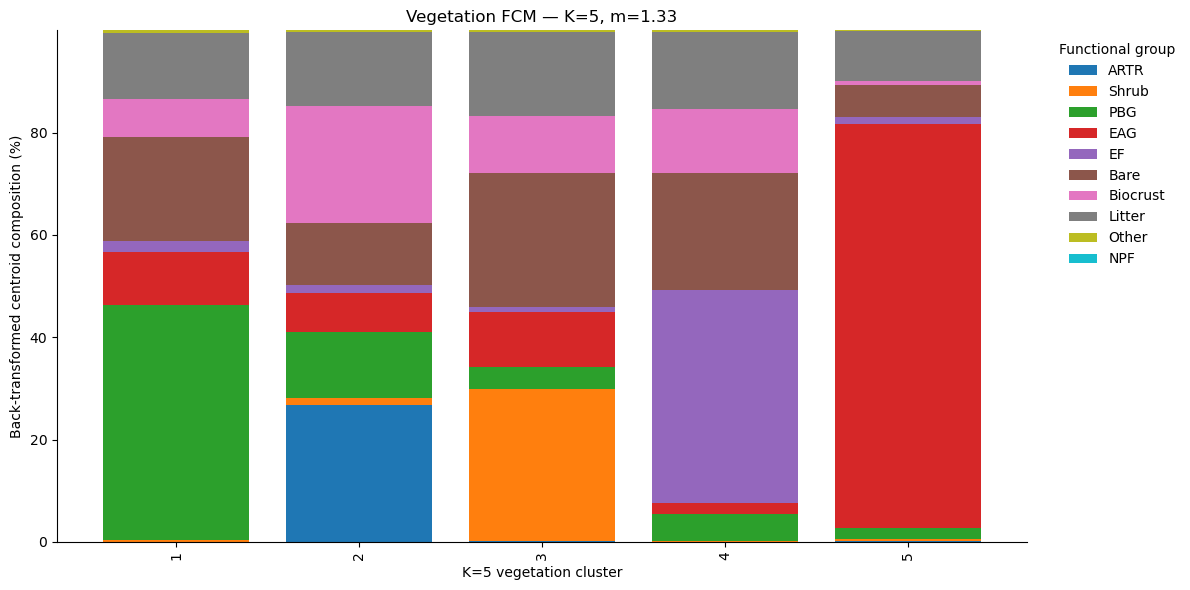

In [20]:
# =============================================================================
# 7. CENTROID COMPOSITION
# =============================================================================

plot_cols = [
    FG_LABELS[fg]
    for fg in FG_ALL
]

plot_df = (
    centroid_table
    .set_index("cluster_k5")[plot_cols]
)

ax = plot_df.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6),
    width=0.8,
)

ax.set_xlabel("K=5 vegetation cluster")
ax.set_ylabel("Back-transformed centroid composition (%)")
ax.set_title("Vegetation FCM — K=5, m=1.33")

ax.legend(
    title="Functional group",
    bbox_to_anchor=(1.02, 1.0),
    loc="upper left",
    frameon=False,
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## 8. Species subcluster diagnostics within the K=5 parents

This reproduces the earlier species-level diagnostic logic rather than inventing a new subclustering method.

For each K=5 parent:

1. retain the **reference/core observations** with parent membership \(u_{\max}\ge0.60\);
2. construct a species-composition matrix, excluding surface fields and the functional-group columns;
3. row-close species cover and apply a Hellinger transformation;
4. fit KMeans for subcluster \(k=2,\ldots,6\) with `n_init=50`, `random_state=42`, and `max_iter=1000`;
5. report inertia, silhouette, minimum occupancy, and the full subcluster distribution;
6. project each fitted solution to **all positive-species observations** assigned to that K=5 parent.

No subcluster K is treated as final automatically. The silhouette-best K is reported only as a diagnostic convenience.

In [21]:
# =============================================================================
# 8. SPECIES MATRIX + SUBCLUSTER SETTINGS
# =============================================================================

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

SUB_K_VALUES = range(2, 7)
N_INIT_SUB = 50
SUB_MAX_ITER = 1000

SUBCLUSTER_DIR = OUTPUT_DIR / "Subclusters"
SUB_TABLE_DIR = SUBCLUSTER_DIR / "Tables"
SUB_FIG_DIR = SUBCLUSTER_DIR / "Figures"

for d in [
    SUBCLUSTER_DIR,
    SUB_TABLE_DIR,
    SUB_FIG_DIR,
]:
    d.mkdir(
        parents=True,
        exist_ok=True,
    )


SURFACE_SPECIES_COLUMNS = {
    "BAREGROUND",
    "BIOCRUST",
    "LITTER",
    "ROCK",
    "SHIT",
    "TRASH",
}


if (
    "Year" not in veg_k5.columns
    or "total_cover" not in veg_k5.columns
):
    raise ValueError(
        "Expected both 'Year' and 'total_cover' in the vegetation master."
    )


year_idx = veg_k5.columns.get_loc(
    "Year"
)

total_idx = veg_k5.columns.get_loc(
    "total_cover"
)

species_surface_cols = list(
    veg_k5.columns[
        year_idx + 1 : total_idx
    ]
)

species_cols = [
    c
    for c in species_surface_cols
    if c not in SURFACE_SPECIES_COLUMNS
    and not c.endswith("_FG")
]


print(
    "Species/surface columns in schema:",
    len(species_surface_cols),
)

print(
    "Vegetation/species columns used for taxonomic subclustering:",
    len(species_cols),
)

print(
    "Subcluster K sweep:",
    list(SUB_K_VALUES),
)

Species/surface columns in schema: 70
Vegetation/species columns used for taxonomic subclustering: 67
Subcluster K sweep: [2, 3, 4, 5, 6]


In [22]:
# =============================================================================
# 9. SPECIES HELLINGER HELPER + DIAGNOSTIC SWEEP
# =============================================================================

def species_hellinger(
    frame: pd.DataFrame,
):

    raw = (
        frame[species_cols]
        .apply(
            pd.to_numeric,
            errors="coerce",
        )
        .fillna(0.0)
    )

    totals = raw.sum(
        axis=1
    ).to_numpy(
        dtype=np.float64
    )

    keep = (
        totals
        > 0
    )

    H = np.full(
        (
            len(frame),
            len(species_cols),
        ),
        np.nan,
        dtype=np.float64,
    )

    if np.any(
        keep
    ):

        prop = (
            raw.to_numpy(
                dtype=np.float64
            )[keep]
            / totals[
                keep,
                None,
            ]
        )

        H[
            keep
        ] = np.sqrt(
            prop
        )

    return (
        H,
        totals,
        keep,
    )


subcluster_results = []
subcluster_distribution_rows = []
subcluster_fits = {}


for parent in range(
    1,
    K + 1,
):

    parent_label = K5_LABELS[
        parent
    ]

    parent_all = veg_k5.loc[
        veg_k5[
            "parent_cluster_k5"
        ].eq(
            parent
        )
    ].copy()

    parent_core = parent_all.loc[
        parent_all[
            "max_membership_k5"
        ].ge(
            CORE_MEMBERSHIP
        )
    ].copy()


    H_core_full, core_totals, core_keep = species_hellinger(
        parent_core
    )

    H_all_full, all_totals, all_keep = species_hellinger(
        parent_all
    )


    core_positive = parent_core.loc[
        core_keep
    ].copy()

    all_positive = parent_all.loc[
        all_keep
    ].copy()

    H_core = H_core_full[
        core_keep
    ]

    H_all = H_all_full[
        all_keep
    ]


    print(
        "\n"
        + "=" * 88
    )

    print(
        f"K5 PARENT {parent} — {parent_label}"
    )

    print(
        "=" * 88
    )

    print(
        f"hard-assigned n:          {len(parent_all):,}"
    )

    print(
        f"core u>=0.60 n:           {len(parent_core):,}"
    )

    print(
        f"core positive-species n:  {len(core_positive):,}"
    )

    print(
        f"all positive-species n:   {len(all_positive):,}"
    )

    print(
        f"zero-species hard rows:   {int((~all_keep).sum()):,}"
    )


    if len(
        core_positive
    ) < 10:

        print(
            "Too few positive-species core observations for diagnostic subclustering."
        )

        continue


    for sub_k in SUB_K_VALUES:

        if len(
            core_positive
        ) <= sub_k:
            continue


        km = KMeans(
            n_clusters=sub_k,
            random_state=RANDOM_STATE,
            n_init=N_INIT_SUB,
            max_iter=SUB_MAX_ITER,
        )

        core_labels = km.fit_predict(
            H_core
        )

        counts_core = (
            pd.Series(
                core_labels
            )
            .value_counts()
            .sort_index()
        )

        silhouette = silhouette_score(
            H_core,
            core_labels,
            metric="euclidean",
        )


        # Project this parent-specific taxonomic solution to every
        # positive-species observation whose hard K5 parent is this parent.
        all_labels = km.predict(
            H_all
        )

        counts_all = (
            pd.Series(
                all_labels
            )
            .value_counts()
            .sort_index()
        )


        subcluster_fits[
            (
                parent,
                sub_k,
            )
        ] = km


        subcluster_results.append(
            {
                "parent_cluster_k5": parent,
                "parent_label_k5": parent_label,
                "sub_k": sub_k,
                "n_parent_hard": len(parent_all),
                "n_parent_core": len(parent_core),
                "n_core_species_positive": len(core_positive),
                "n_all_species_positive": len(all_positive),
                "n_zero_species": int((~all_keep).sum()),
                "inertia": float(km.inertia_),
                "silhouette": float(silhouette),
                "min_subcluster_n_core": int(counts_core.min()),
                "max_subcluster_n_core": int(counts_core.max()),
                "min_subcluster_fraction_core": float(
                    counts_core.min()
                    / len(core_positive)
                ),
            }
        )


        for raw_subcluster in range(
            sub_k
        ):

            n_core_sub = int(
                counts_core.get(
                    raw_subcluster,
                    0,
                )
            )

            n_all_sub = int(
                counts_all.get(
                    raw_subcluster,
                    0,
                )
            )

            subcluster_distribution_rows.append(
                {
                    "parent_cluster_k5": parent,
                    "parent_label_k5": parent_label,
                    "sub_k": sub_k,
                    "subcluster": raw_subcluster + 1,
                    "n_core": n_core_sub,
                    "core_fraction": (
                        n_core_sub
                        / len(core_positive)
                    ),
                    "n_all_projected": n_all_sub,
                    "all_projected_fraction": (
                        n_all_sub
                        / len(all_positive)
                    ),
                }
            )


        print(
            f"k={sub_k} | "
            f"inertia={km.inertia_:.3f} | "
            f"silhouette={silhouette:.3f} | "
            f"min core n={int(counts_core.min()):3d} | "
            f"min core frac={counts_core.min()/len(core_positive):.3f}"
        )


subcluster_diagnostics = pd.DataFrame(
    subcluster_results
)

subcluster_distribution = pd.DataFrame(
    subcluster_distribution_rows
)


DIAGNOSTICS_PATH = (
    SUB_TABLE_DIR
    / "K5_species_subcluster_diagnostics_k2to6.csv"
)

DISTRIBUTION_PATH = (
    SUB_TABLE_DIR
    / "K5_species_subcluster_distributions_k2to6.csv"
)

subcluster_diagnostics.to_csv(
    DIAGNOSTICS_PATH,
    index=False,
)

subcluster_distribution.to_csv(
    DISTRIBUTION_PATH,
    index=False,
)


print(
    "\nSubcluster diagnostics:"
)

display(
    subcluster_diagnostics.sort_values(
        [
            "parent_cluster_k5",
            "sub_k",
        ]
    ).round(
        4
    )
)

print(
    "\nWrote:"
)

print(
    " ",
    DIAGNOSTICS_PATH,
)

print(
    " ",
    DISTRIBUTION_PATH,
)


K5 PARENT 1 — PBG
hard-assigned n:          245
core u>=0.60 n:           189
core positive-species n:  189
all positive-species n:   245
zero-species hard rows:   0
k=2 | inertia=78.930 | silhouette=0.280 | min core n= 82 | min core frac=0.434
k=3 | inertia=58.785 | silhouette=0.359 | min core n= 45 | min core frac=0.238
k=4 | inertia=50.681 | silhouette=0.390 | min core n= 13 | min core frac=0.069
k=5 | inertia=44.927 | silhouette=0.405 | min core n= 12 | min core frac=0.063
k=6 | inertia=40.882 | silhouette=0.334 | min core n= 13 | min core frac=0.069

K5 PARENT 2 — ARTR
hard-assigned n:          146
core u>=0.60 n:           115
core positive-species n:  115
all positive-species n:   146
zero-species hard rows:   0
k=2 | inertia=26.780 | silhouette=0.219 | min core n= 45 | min core frac=0.391
k=3 | inertia=22.702 | silhouette=0.218 | min core n= 29 | min core frac=0.252
k=4 | inertia=20.519 | silhouette=0.227 | min core n= 11 | min core frac=0.096
k=5 | inertia=18.701 | silhouette

,parent_cluster_k5,parent_label_k5,sub_k,n_parent_hard,n_parent_core,n_core_species_positive,n_all_species_positive,n_zero_species,inertia,silhouette,min_subcluster_n_core,max_subcluster_n_core,min_subcluster_fraction_core
0,1,PBG,2,245,189,189,245,0,78.9298,0.2797,82,107,0.4339
1,1,PBG,3,245,189,189,245,0,58.7847,0.3588,45,81,0.2381
2,1,PBG,4,245,189,189,245,0,50.6814,0.3900,13,77,0.0688
3,1,PBG,5,245,189,189,245,0,44.9271,0.4052,12,74,0.0635
4,1,PBG,6,245,189,189,245,0,40.8818,0.3344,13,71,0.0688
5,2,ARTR,2,146,115,115,146,0,26.7805,0.2185,45,70,0.3913
6,2,ARTR,3,146,115,115,146,0,22.7015,0.2182,29,47,0.2522
7,2,ARTR,4,146,115,115,146,0,20.5190,0.2272,11,45,0.0957
8,2,ARTR,5,146,115,115,146,0,18.7008,0.2100,9,44,0.0783
9,2,ARTR,6,146,115,115,146,0,17.2130,0.2093,9,37,0.0783



Wrote:
  C:\NCA_DATA\Vegetation Data\Clustering_Veg\K5_m1p33_Subclusters\Subclusters\Tables\K5_species_subcluster_diagnostics_k2to6.csv
  C:\NCA_DATA\Vegetation Data\Clustering_Veg\K5_m1p33_Subclusters\Subclusters\Tables\K5_species_subcluster_distributions_k2to6.csv


## 10. Diagnostic best-by-silhouette hierarchy and parent/subcluster distribution

This section chooses the maximum-silhouette subcluster K **only for visualization and inspection**. It is not declared to be the final ecological subcluster architecture.

Each parent-specific model was fit on the high-membership core and is then projected to all positive-species observations in that parent. Zero-species observations are reported separately rather than forced into a taxonomic cluster.

In [23]:
# =============================================================================
# 10. BEST-BY-SILHOUETTE DIAGNOSTIC HIERARCHY
# =============================================================================

if subcluster_diagnostics.empty:
    raise RuntimeError(
        "No subcluster diagnostic fits were produced."
    )


best_k_by_parent = (
    subcluster_diagnostics
    .sort_values(
        [
            "parent_cluster_k5",
            "silhouette",
            "min_subcluster_fraction_core",
        ],
        ascending=[
            True,
            False,
            False,
        ],
    )
    .groupby(
        "parent_cluster_k5",
        as_index=False,
    )
    .first()
    [
        [
            "parent_cluster_k5",
            "parent_label_k5",
            "sub_k",
            "silhouette",
            "min_subcluster_n_core",
            "min_subcluster_fraction_core",
        ]
    ]
)

best_k_by_parent = best_k_by_parent.rename(
    columns={
        "sub_k": "diagnostic_best_sub_k",
    }
)


BEST_K_PATH = (
    SUB_TABLE_DIR
    / "K5_species_subcluster_bestK_by_silhouette_DIAGNOSTIC.csv"
)

best_k_by_parent.to_csv(
    BEST_K_PATH,
    index=False,
)


print(
    "Diagnostic best subcluster K by silhouette:"
)

display(
    best_k_by_parent.round(
        4
    )
)


# -----------------------------------------------------------------------------
# PROJECT DIAGNOSTIC-BEST SUBCLUSTER MODEL TO ALL POSITIVE-SPECIES ROWS
# -----------------------------------------------------------------------------

veg_k5_sub = veg_k5.copy()

# Attach ecological K5 parent labels to the observation-level table.
veg_k5_sub[
    "parent_label_k5"
] = (
    veg_k5_sub[
        "parent_cluster_k5"
    ]
    .map(
        K5_LABELS
    )
)


if veg_k5_sub[
    "parent_label_k5"
].isna().any():

    raise ValueError(
        "One or more K5 parent clusters did not map to K5_LABELS."
    )

veg_k5_sub[
    "species_total"
] = (
    veg_k5_sub[species_cols]
    .apply(
        pd.to_numeric,
        errors="coerce",
    )
    .fillna(0.0)
    .sum(
        axis=1
    )
)

veg_k5_sub[
    "diagnostic_sub_k"
] = np.nan

veg_k5_sub[
    "diagnostic_subcluster"
] = np.nan

veg_k5_sub[
    "diagnostic_state_id"
] = pd.NA


for row in best_k_by_parent.itertuples(
    index=False
):

    parent = int(
        row.parent_cluster_k5
    )

    sub_k = int(
        row.diagnostic_best_sub_k
    )

    km = subcluster_fits[
        (
            parent,
            sub_k,
        )
    ]


    idx = veg_k5_sub.index[
        veg_k5_sub[
            "parent_cluster_k5"
        ].eq(
            parent
        )
        & veg_k5_sub[
            "species_total"
        ].gt(
            0
        )
    ]

    if len(
        idx
    ) == 0:
        continue


    H_all, totals, keep = species_hellinger(
        veg_k5_sub.loc[
            idx
        ]
    )

    if not np.all(
        keep
    ):
        raise RuntimeError(
            f"Unexpected zero-species row during parent {parent} projection."
        )


    pred = (
        km.predict(
            H_all
        )
        + 1
    )

    veg_k5_sub.loc[
        idx,
        "diagnostic_sub_k",
    ] = sub_k

    veg_k5_sub.loc[
        idx,
        "diagnostic_subcluster",
    ] = pred

    veg_k5_sub.loc[
        idx,
        "diagnostic_state_id",
    ] = [
        f"{parent}.{int(s)}"
        for s in pred
    ]


BEST_ASSIGNMENTS_PATH = (
    SUBCLUSTER_DIR
    / "NCA_K5_species_subclusters_bestSilhouette_DIAGNOSTIC.csv"
)

veg_k5_sub.to_csv(
    BEST_ASSIGNMENTS_PATH,
    index=False,
)


# -----------------------------------------------------------------------------
# PARENT + SUBCLUSTER DISTRIBUTION
# -----------------------------------------------------------------------------

best_distribution = (
    veg_k5_sub.loc[
        veg_k5_sub[
            "diagnostic_state_id"
        ].notna()
    ]
    .groupby(
        [
            "parent_cluster_k5",
            "parent_label_k5",
            "diagnostic_sub_k",
            "diagnostic_subcluster",
            "diagnostic_state_id",
        ],
        as_index=False,
    )
    .size()
    .rename(
        columns={
            "size": "n_all_projected",
        }
    )
)

best_distribution[
    "parent_total_positive_species"
] = (
    best_distribution
    .groupby(
        "parent_cluster_k5"
    )[
        "n_all_projected"
    ]
    .transform(
        "sum"
    )
)

best_distribution[
    "fraction_within_parent"
] = (
    best_distribution[
        "n_all_projected"
    ]
    / best_distribution[
        "parent_total_positive_species"
    ]
)


BEST_DISTRIBUTION_PATH = (
    SUB_TABLE_DIR
    / "K5_parent_subcluster_distribution_bestSilhouette_DIAGNOSTIC.csv"
)

best_distribution.to_csv(
    BEST_DISTRIBUTION_PATH,
    index=False,
)


print(
    "\nParent + diagnostic subcluster distribution:"
)

display(
    best_distribution.round(
        {
            "fraction_within_parent": 3,
        }
    )
)


# -----------------------------------------------------------------------------
# ZERO-SPECIES COUNTS BY PARENT
# -----------------------------------------------------------------------------

zero_species_by_parent = (
    veg_k5_sub.loc[
        veg_k5_sub[
            "species_total"
        ].le(
            0
        )
    ]
    .groupby(
        [
            "parent_cluster_k5",
            "parent_label_k5",
        ],
        as_index=False,
    )
    .size()
    .rename(
        columns={
            "size": "n_zero_species",
        }
    )
)

ZERO_SPECIES_PATH = (
    SUB_TABLE_DIR
    / "K5_zero_species_by_parent.csv"
)

zero_species_by_parent.to_csv(
    ZERO_SPECIES_PATH,
    index=False,
)


print(
    "\nZero-species rows by K5 parent:"
)

display(
    zero_species_by_parent
)

Diagnostic best subcluster K by silhouette:


,parent_cluster_k5,parent_label_k5,diagnostic_best_sub_k,silhouette,min_subcluster_n_core,min_subcluster_fraction_core
0,1,PBG,5,0.4052,12,0.0635
1,2,ARTR,4,0.2272,11,0.0957
2,3,Non-ARTR shrub,4,0.3792,22,0.1294
3,4,Exotic forb,6,0.3905,15,0.0882
4,5,EAG,5,0.2914,20,0.0619



Parent + diagnostic subcluster distribution:


,parent_cluster_k5,parent_label_k5,diagnostic_sub_k,diagnostic_subcluster,diagnostic_state_id,n_all_projected,parent_total_positive_species,fraction_within_parent
0,1,PBG,5.0,1.0,1.1,74,245,0.302
1,1,PBG,5.0,2.0,1.2,106,245,0.433
2,1,PBG,5.0,3.0,1.3,23,245,0.094
3,1,PBG,5.0,4.0,1.4,16,245,0.065
4,1,PBG,5.0,5.0,1.5,26,245,0.106
5,2,ARTR,4.0,1.0,2.1,12,146,0.082
6,2,ARTR,4.0,2.0,2.2,49,146,0.336
7,2,ARTR,4.0,3.0,2.3,58,146,0.397
8,2,ARTR,4.0,4.0,2.4,27,146,0.185
9,3,Non-ARTR shrub,4.0,1.0,3.1,45,204,0.221



Zero-species rows by K5 parent:


,parent_cluster_k5,parent_label_k5,n_zero_species
0,3,Non-ARTR shrub,4
1,4,Exotic forb,1
2,5,EAG,1


## 11. Ecological summaries of the diagnostic subclusters

The table below reports the most abundant species in each diagnostic subcluster and the functional-group means of the observations projected into it. This is for interpretation of the hierarchy, not for canonical naming yet.

,state_id,parent_cluster_k5,parent_label_k5,n,mean_parent_membership,top_species_mean_cover,ARTR,Shrub,PBG,EAG,EF,Bare,Biocrust,Litter,Other,NPF
0,1.1,1,PBG,74,0.828913,AGCR:31.09; BRTE:16.87; POSE:4.60; OTHER:1.06;...,0.108108,1.021892,36.398904,16.871847,1.314204,20.648018,8.505676,13.828574,1.279625,0.000000
1,1.2,1,PBG,106,0.723446,POSE:38.13; BRTE:9.52; SIAL2:3.03; SATR12:1.17...,0.485624,1.606217,40.570740,9.726187,7.752668,18.211644,9.176101,11.934780,0.528302,0.000000
2,1.3,1,PBG,23,0.853037,PBG:33.03; BRTE:9.65; ELYMUS:3.11; POSE:1.57; ...,0.035652,0.589565,39.826149,9.650621,0.987174,23.904224,5.386957,19.141056,0.436770,0.000000
3,1.4,1,PBG,16,0.780698,PSSP6:36.73; BRTE:7.44; POSE:6.31; OTHER:2.60;...,0.275000,2.237500,45.862500,9.250000,0.362500,19.287500,13.862500,5.725000,3.137500,0.000000
4,1.5,1,PBG,26,0.763252,BRTE:15.40; ACTH7:9.48; ELYMUS:8.84; HECO:4.46...,0.063077,1.924615,34.048846,15.404487,1.734615,23.007372,9.759808,11.086026,2.892821,0.046154
5,2.1,2,ARTR,12,0.822921,ARTR2:22.15; AGCR:7.83; CHVI8:6.76; POSE:3.71;...,22.154259,6.944444,14.610000,1.422222,0.016667,19.288333,23.516667,8.501111,3.535185,0.000000
6,2.2,2,ARTR,49,0.775929,ARTR2:21.92; BRTE:21.75; POSE:6.99; SATR12D:1....,22.026213,3.066984,7.797007,21.782268,0.891020,13.985760,16.371655,13.624354,0.441270,0.000000
7,2.3,2,ARTR,58,0.786661,ARTR2:25.38; POSE:19.41; CETE5:2.33; SIAL2:1.5...,26.091293,2.934483,20.824138,3.563707,4.955172,8.221523,22.580460,10.531638,0.237931,0.054310
8,2.4,2,ARTR,27,0.713709,ARTR2:28.55; CETE5:5.89; SATR12D:3.33; KRLA2:1...,28.741728,1.866667,1.131852,0.453333,6.731481,19.031852,21.829630,19.583086,0.536420,0.170370
9,3.1,3,Non-ARTR shrub,45,0.722764,BRTE:24.40; SAVE4:7.88; ERNA10:3.99; ATCA2:2.7...,2.379753,20.025284,2.213728,24.704099,0.904000,28.531901,8.049136,12.376099,0.788000,0.000000


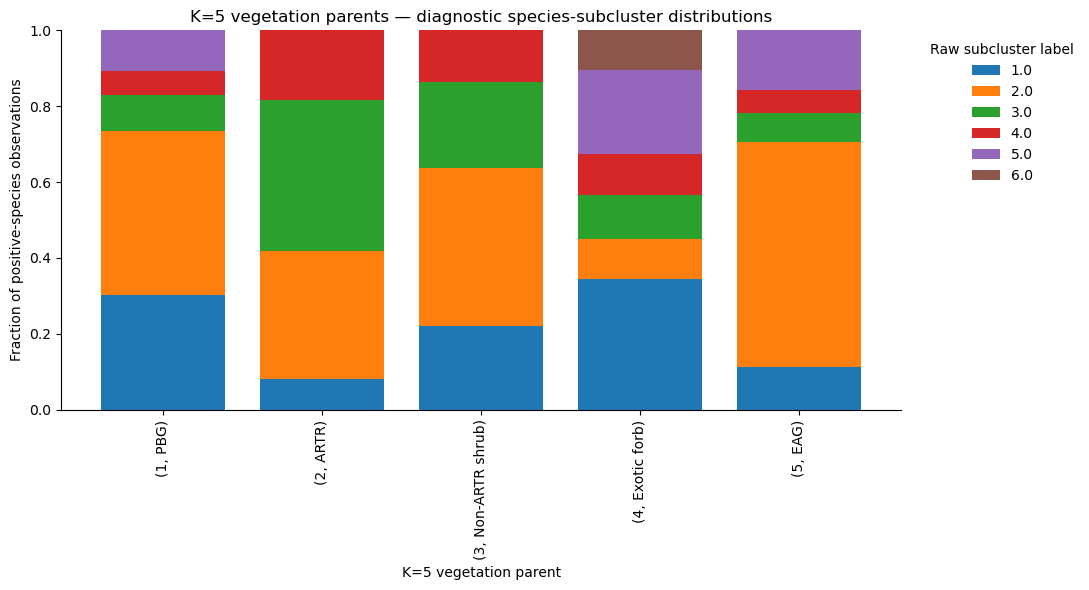

In [24]:
# =============================================================================
# 11. SUBCLUSTER ECOLOGICAL SUMMARIES
# =============================================================================

summary_rows = []

for state_id in sorted(
    veg_k5_sub.loc[
        veg_k5_sub[
            "diagnostic_state_id"
        ].notna(),
        "diagnostic_state_id",
    ].unique(),
    key=lambda x: tuple(
        int(v)
        for v in str(x).split(".")
    ),
):

    g = veg_k5_sub.loc[
        veg_k5_sub[
            "diagnostic_state_id"
        ].eq(
            state_id
        )
    ].copy()

    parent = int(
        str(state_id).split(".")[0]
    )


    species_means = (
        g[species_cols]
        .apply(
            pd.to_numeric,
            errors="coerce",
        )
        .fillna(0.0)
        .mean()
        .sort_values(
            ascending=False
        )
    )

    top_species = [
        f"{sp}:{species_means.loc[sp]:.2f}"
        for sp in species_means.head(
            8
        ).index
        if species_means.loc[
            sp
        ] > 0
    ]


    fg_means = (
        g[FG_ALL]
        .apply(
            pd.to_numeric,
            errors="coerce",
        )
        .mean()
    )


    row = {
        "state_id": state_id,
        "parent_cluster_k5": parent,
        "parent_label_k5": K5_LABELS[parent],
        "n": len(g),
        "mean_parent_membership": g[
            "max_membership_k5"
        ].mean(),
        "top_species_mean_cover": "; ".join(
            top_species
        ),
    }

    for fg in FG_ALL:
        row[
            FG_LABELS[
                fg
            ]
        ] = fg_means[
            fg
        ]

    summary_rows.append(
        row
    )


subcluster_ecology = pd.DataFrame(
    summary_rows
)


ECOLOGY_PATH = (
    SUB_TABLE_DIR
    / "K5_subcluster_ecological_summary_bestSilhouette_DIAGNOSTIC.csv"
)

subcluster_ecology.to_csv(
    ECOLOGY_PATH,
    index=False,
)


display(
    subcluster_ecology
)


# -----------------------------------------------------------------------------
# DISTRIBUTION FIGURE
# -----------------------------------------------------------------------------

plot_dist = (
    best_distribution
    .pivot(
        index=[
            "parent_cluster_k5",
            "parent_label_k5",
        ],
        columns="diagnostic_subcluster",
        values="fraction_within_parent",
    )
    .fillna(
        0.0
    )
)

ax = plot_dist.plot(
    kind="bar",
    stacked=True,
    figsize=(
        11,
        6,
    ),
    width=0.78,
)

ax.set_xlabel(
    "K=5 vegetation parent"
)

ax.set_ylabel(
    "Fraction of positive-species observations"
)

ax.set_title(
    "K=5 vegetation parents — diagnostic species-subcluster distributions"
)

ax.legend(
    title="Raw subcluster label",
    bbox_to_anchor=(
        1.02,
        1.0,
    ),
    loc="upper left",
    frameon=False,
)

ax.spines[
    "top"
].set_visible(
    False
)

ax.spines[
    "right"
].set_visible(
    False
)

plt.tight_layout()
plt.show()

## 12. Optional K=8 parent composition within the diagnostic K5 subclusters

This cross-tab helps answer the hierarchy question directly: do the species-level subclusters inside the five coarse parents recover recognizable pieces of the retained K=8 parent solution?

In [25]:
# =============================================================================
# 12. K8 COMPOSITION WITHIN K5 SPECIES SUBCLUSTERS
# =============================================================================

if K8_ASSIGNMENTS_PATH.exists():

    k8 = pd.read_csv(
        K8_ASSIGNMENTS_PATH,
        low_memory=False,
    ).drop(
        columns=[
            "Unnamed: 0",
        ],
        errors="ignore",
    )


    candidate_keys = [
        [
            "Plot",
            "Year",
        ],
        [
            "PlotID",
            "Year",
        ],
    ]

    JOIN_KEYS = None

    for keys in candidate_keys:

        if (
            all(
                c in veg_k5_sub.columns
                for c in keys
            )
            and all(
                c in k8.columns
                for c in keys
            )
        ):

            JOIN_KEYS = keys
            break


    if JOIN_KEYS is None:
        raise KeyError(
            "Could not find a shared Plot-Year or PlotID-Year key."
        )


    k8_small = k8[
        JOIN_KEYS
        + [
            "parent_cluster",
        ]
    ].copy()


    hierarchy = (
        veg_k5_sub.loc[
            veg_k5_sub[
                "diagnostic_state_id"
            ].notna(),
            JOIN_KEYS
            + [
                "parent_cluster_k5",
                "parent_label_k5",
                "diagnostic_state_id",
            ],
        ]
        .merge(
            k8_small,
            on=JOIN_KEYS,
            how="left",
            validate="one_to_one",
        )
        .rename(
            columns={
                "parent_cluster": "parent_cluster_k8",
            }
        )
    )


    k8_by_state_counts = pd.crosstab(
        hierarchy[
            "diagnostic_state_id"
        ],
        hierarchy[
            "parent_cluster_k8"
        ],
    )

    k8_by_state_prop = pd.crosstab(
        hierarchy[
            "diagnostic_state_id"
        ],
        hierarchy[
            "parent_cluster_k8"
        ],
        normalize="index",
    )


    K8_STATE_COUNTS_PATH = (
        SUB_TABLE_DIR
        / "K8_parent_by_K5_diagnostic_subcluster_counts.csv"
    )

    K8_STATE_PROP_PATH = (
        SUB_TABLE_DIR
        / "K8_parent_by_K5_diagnostic_subcluster_rowProportions.csv"
    )

    k8_by_state_counts.to_csv(
        K8_STATE_COUNTS_PATH
    )

    k8_by_state_prop.to_csv(
        K8_STATE_PROP_PATH
    )


    print(
        "K8 parent counts inside diagnostic K5 species subclusters:"
    )

    display(
        k8_by_state_counts
    )

    print(
        "\nK8 parent proportions inside diagnostic K5 species subclusters:"
    )

    display(
        k8_by_state_prop.round(
            3
        )
    )

else:

    print(
        "K8 assignment file not found; skipping K8 ↔ K5-subcluster crosswalk."
    )

K8 parent counts inside diagnostic K5 species subclusters:


parent_cluster_k8,1,2,3,4,5,6,7,8
diagnostic_state_id,,,,,,,,
1.1,0,0,0,0,39,35,0,0
1.2,0,3,0,0,55,20,0,28
1.3,0,0,0,0,17,6,0,0
1.4,0,0,0,0,12,4,0,0
1.5,1,0,0,0,16,9,0,0
2.1,0,0,0,0,0,0,12,0
2.2,8,0,0,0,0,1,40,0
2.3,0,4,0,0,2,0,46,6
2.4,0,1,2,0,0,0,24,0



K8 parent proportions inside diagnostic K5 species subclusters:


parent_cluster_k8,1,2,3,4,5,6,7,8
diagnostic_state_id,,,,,,,,
1.1,0.000,0.000,0.000,0.000,0.527,0.473,0.000,0.000
1.2,0.000,0.028,0.000,0.000,0.519,0.189,0.000,0.264
1.3,0.000,0.000,0.000,0.000,0.739,0.261,0.000,0.000
1.4,0.000,0.000,0.000,0.000,0.750,0.250,0.000,0.000
1.5,0.038,0.000,0.000,0.000,0.615,0.346,0.000,0.000
2.1,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000
2.2,0.163,0.000,0.000,0.000,0.000,0.020,0.816,0.000
2.3,0.000,0.069,0.000,0.000,0.034,0.000,0.793,0.103
2.4,0.000,0.037,0.074,0.000,0.000,0.000,0.889,0.000


## 13. Output manifest

The key outputs are:

- `Derived/NCA_FCM_K5_m1p33_parent_assignments.csv`
- `Derived/NCA_FCM_K5_m1p33_model.npz`
- `Tables/K5_m1p33_parent_centroids_and_membership.csv`
- `Tables/K5_m1p33_FCM_metrics.csv`
- K8↔K5 crosswalk tables when the retained K=8 assignment file is present

The K=5 hard labels can then be used as the response in the supervised optical / optical+POLARIS comparison without changing the predictor architecture.

This version writes to the separate `K5_m1p33_Subclusters` root, so the earlier `K5_m1p33` parent run is not overwritten.

In [26]:
# =============================================================================
# 13. MANIFEST / QA
# =============================================================================

print("=" * 78)
print("K=5 VEGETATION FCM COMPLETE")
print("=" * 78)

print(f"\nRows clustered:       {len(veg_k5):,}")
print(f"Clusters:             {veg_k5['parent_cluster_k5'].nunique()}")
print(f"m:                    {M:.2f}")
print(f"Best seed:            {best_fit['seed']}")
print(f"Objective:            {best_fit['objective']:.6f}")
print(f"Restart ARI mean:     {restart_ari.mean():.4f}")
print(f"Reference rows u≥.60: {int(veg_k5['is_reference_k5'].sum()):,}")

print("\nDERIVED")
for p in sorted(DERIVED_DIR.glob("*")):
    print(" ", p)

print("\nTABLES")
for p in sorted(TABLE_DIR.glob("*")):
    print(" ", p)

print(
    "\nSUBCLUSTER TABLES"
)

for p in sorted(
    SUB_TABLE_DIR.glob(
        "*"
    )
):

    print(
        " ",
        p
    )

print(
    "\nSUBCLUSTER ROOT"
)

for p in sorted(
    SUBCLUSTER_DIR.glob(
        "*"
    )
):

    if p.is_file():
        print(
            " ",
            p
        )


K=5 VEGETATION FCM COMPLETE

Rows clustered:       1,171
Clusters:             5
m:                    1.33
Best seed:            50
Objective:            220.049659
Restart ARI mean:     0.8008
Reference rows u≥.60: 968

DERIVED
  C:\NCA_DATA\Vegetation Data\Clustering_Veg\K5_m1p33_Subclusters\Derived\NCA_FCM_K5_m1p33_model.npz
  C:\NCA_DATA\Vegetation Data\Clustering_Veg\K5_m1p33_Subclusters\Derived\NCA_FCM_K5_m1p33_parent_assignments.csv

TABLES
  C:\NCA_DATA\Vegetation Data\Clustering_Veg\K5_m1p33_Subclusters\Tables\K5_m1p33_FCM_metrics.csv
  C:\NCA_DATA\Vegetation Data\Clustering_Veg\K5_m1p33_Subclusters\Tables\K5_m1p33_parent_centroids_and_membership.csv
  C:\NCA_DATA\Vegetation Data\Clustering_Veg\K5_m1p33_Subclusters\Tables\K8_to_K5_crosswalk_counts.csv
  C:\NCA_DATA\Vegetation Data\Clustering_Veg\K5_m1p33_Subclusters\Tables\K8_to_K5_crosswalk_row_proportions.csv
  C:\NCA_DATA\Vegetation Data\Clustering_Veg\K5_m1p33_Subclusters\Tables\K8_to_K5_partition_similarity.csv

SUBCLUST